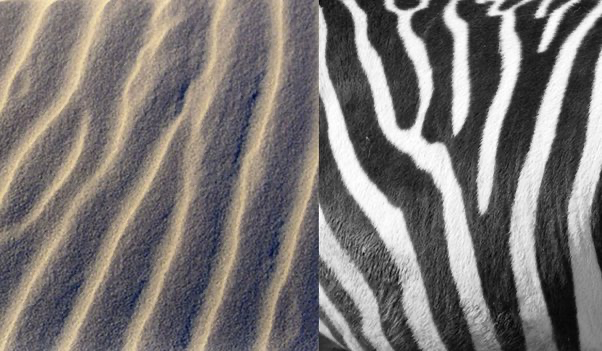

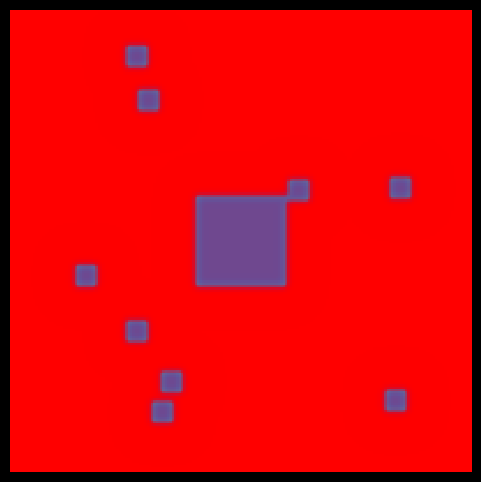

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------------------------
# Parameters
# ---------------------------
L = 200               # grid size
Du, Dv = 0.16, 0.08   # diffusion rates
F, k = 0.060, 0.062   # feed and kill rates
dt = 1.0              # time step
steps_per_frame = 20  # sim steps per animation frame

# ---------------------------
# Initialize fields
# ---------------------------
U = np.ones((L, L))
V = np.zeros((L, L))

# Random blob initialization
r = 20
U[L//2-r:L//2+r, L//2-r:L//2+r] = 0.50
V[L//2-r:L//2+r, L//2-r:L//2+r] = 0.25
for _ in range(10):
    x, y = np.random.randint(20, L-20, 2)
    U[x-5:x+5, y-5:y+5] = 0.50
    V[x-5:x+5, y-5:y+5] = 0.25

# Laplacian kernel
lap_kernel = np.array([[0.05, 0.2, 0.05],
                       [0.2 , -1.0, 0.2 ],
                       [0.05, 0.2, 0.05]])

def laplacian(Z):
    return np.array([[np.sum(lap_kernel * Z[i-1:i+2, j-1:j+2])
                      for j in range(1, L-1)]
                      for i in range(1, L-1)])

# ---------------------------
# Animation setup
# ---------------------------
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(np.zeros((L, L, 3)), interpolation='nearest')
ax.axis('off')

def update(_):
    global U, V
    for _ in range(steps_per_frame):
        Lu, Lv = laplacian(U), laplacian(V)
        uvv = U[1:-1, 1:-1] * V[1:-1, 1:-1]**2

        U[1:-1, 1:-1] += dt * (Du * Lu - uvv + F * (1 - U[1:-1, 1:-1]))
        V[1:-1, 1:-1] += dt * (Dv * Lv + uvv - (F + k) * V[1:-1, 1:-1])

        U = np.clip(U, 0, 1)
        V = np.clip(V, 0, 1)

    # Color mapping (RGB mix of U and V)
    R = U
    G = V
    B = 1 - U
    img = np.dstack([R, G, B])
    im.set_data(img)
    return [im]

ani = FuncAnimation(fig, update, frames=500, interval=50, blit=True)
plt.show()

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Parameters
L = 100  # Grid size
F = 0.035
k = 0.060
Du = 0.16
Dv = 0.08
steps = 10000
dt = 1.0

# Initialize U and V
U = np.ones((L, L))
V = np.zeros((L, L))

# Initial perturbation
U[48:52, 48:52] = 0.50
V[48:52, 48:52] = 0.25

# Laplacian kernel
lap_kernel = np.array([[0.05, 0.2, 0.05],
                       [0.2, -1.0, 0.2],
                       [0.05, 0.2, 0.05]])

# Simulation loop (vectorized)
for step in range(steps):
    Lu = convolve(U, lap_kernel, mode='constant', cval=0.0)
    Lv = convolve(V, lap_kernel, mode='constant', cval=0.0)

    uvv = U * V * V

    U += dt * (Du * Lu - uvv + F * (1 - U))
    V += dt * (Dv * Lv + uvv - (F + k) * V)

    # Clamp to [0,1] for stability
    U = np.clip(U, 0, 1)
    V = np.clip(V, 0, 1)

    if step % 100 == 0:
        plt.imshow(U, cmap='inferno')
        plt.title(f'Step {step}')
        plt.axis('off')
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# -----------------------------
# Part 1: Gray-Scott Simulator
# -----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class GrayScottSimulator(nn.Module):
    def __init__(self, img_size=128, dx=1.0, dt=1.0, steps=100, padding='circular', device='cuda'):
        super().__init__()
        self.img_size = img_size
        self.dx = dx
        self.dt = dt
        self.steps = steps
        self.padding = padding
        self.device = device

        # Laplacian kernel
        lap = torch.tensor([[0.0, 1.0, 0.0],
                            [1.0, -4.0, 1.0],
                            [0.0, 1.0, 0.0]], dtype=torch.float32)
        self.register_buffer('lap_kernel', lap.unsqueeze(0).unsqueeze(0))

    def laplacian(self, x):
        """Compute Laplacian safely with padding."""
        B, C, H, W = x.shape
        k = self.lap_kernel.repeat(C, 1, 1, 1)
        if self.padding == 'circular':
            x_p = F.pad(x, (1,1,1,1), mode='circular')
        else:
            x_p = F.pad(x, (1,1,1,1), mode=self.padding)
        return F.conv2d(x_p, k, padding=0, groups=C)

    def forward(self, params):
        """
        params: (B,6) tensor with [F, k, Du, Dv, tfrac, init_amp]
        returns: (B,1,H,W) normalized V channel as the pattern
        """
        device = self.device
        p = params.to(device)
        B = p.shape[0]

        # extract parameters
        Fp = p[:,0:1]
        kp = p[:,1:2]
        Du_raw = p[:,2:3]
        Dv_raw = p[:,3:4]
        tfrac = p[:,4:5]
        init_amp = p[:,5:6]

        # positive diffusion rates
        Du = F.softplus(Du_raw)
        Dv = F.softplus(Dv_raw)

        H = W = self.img_size
        U = torch.ones((B,1,H,W), device=device)
        V = torch.zeros((B,1,H,W), device=device)

        # Add small random perturbations
        noise = (torch.randn((B,1,H,W), device=device)*0.5 + 0.5) * init_amp.view(B,1,1,1)
        U = U - 0.05*noise
        V = V + 0.05*noise

        # Seed patches (out-of-place)
        seed_U = torch.zeros_like(U)
        seed_V = torch.zeros_like(V)
        for b in range(B):
            cx = int(np.random.randint(H//4, 3*H//4))
            cy = int(np.random.randint(W//4, 3*W//4))
            rs = max(1,int(H*0.02*(0.5+np.random.rand())))
            x0,x1 = max(0,cx-rs), min(H,cx+rs)
            y0,y1 = max(0,cy-rs), min(W,cy+rs)
            patch_u = 0.50 + 0.2*torch.rand(1, device=device)
            patch_v = 0.25*torch.rand(1, device=device)
            mask = torch.zeros((1,1,H,W), device=device)
            mask[:,:,x0:x1,y0:y1] = 1.0
            seed_U = seed_U + mask*patch_u
            seed_V = seed_V + mask*patch_v

        U = U + seed_U
        V = V + seed_V

        # Simulation loop
        for t in range(self.steps):
            LU = self.laplacian(U)
            LV = self.laplacian(V)
            UVV = U*V*V
            Fi = Fp.view(B,1,1,1)
            ki = kp.view(B,1,1,1)
            Dui = Du.view(B,1,1,1)
            Dvi = Dv.view(B,1,1,1)

            dU = Dui*LU - UVV + Fi*(1-U)
            dV = Dvi*LV + UVV - (Fi+ki)*V

            # Out-of-place updates
            U = U + self.dt*dU
            V = V + self.dt*dV

            # Clamp to avoid numerical issues
            U = torch.clamp(U, -1.0, 2.0)
            V = torch.clamp(V, -0.5, 2.0)

        # Normalize V channel
        vmin = V.view(B,-1).min(dim=1)[0].view(B,1,1,1)
        vmax = V.view(B,-1).max(dim=1)[0].view(B,1,1,1)
        Vn = (V - vmin) / (vmax - vmin).clamp(min=1e-6)
        return Vn

# -----------------------------
# Example usage in Colab
# -----------------------------
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    sim = GrayScottSimulator(img_size=128, steps=50, device=device)
    params = torch.rand((4,6), device=device)  # 4 samples
    patterns = sim(params)
    print(patterns.shape)  # Should be [4,1,128,128]

torch.Size([4, 1, 128, 128])


In [13]:
# -----------------------------
# Part 2: Dataset + Model (Colab-friendly)
# -----------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Dataset
# -----------------------------
class GrayScottDataset(Dataset):
    def __init__(self, n_samples=2000, img_size=128, simulator=None, precompute=False, cache_path='gs_dataset.pt', device='cuda'):
        super().__init__()
        self.n_samples = n_samples
        self.img_size = img_size
        self.simulator = simulator
        self.precompute = precompute
        self.cache_path = cache_path
        self.device = device

        if self.precompute and self.cache_path and os.path.exists(self.cache_path):
            data = torch.load(self.cache_path, map_location='cpu')
            self.images = data['images']
            self.params = data['params']
        else:
            self.images = None
            self.params = None

    def sample_params(self, bs):
        F = torch.rand(bs,1)*(0.08-0.01)+0.01
        k = torch.rand(bs,1)*(0.07-0.04)+0.04
        Du = torch.rand(bs,1)*(0.6-0.04)+0.04
        Dv = torch.rand(bs,1)*(0.1-0.002)+0.002
        tfrac = torch.rand(bs,1)*(1.0-0.2)+0.2
        init_amp = torch.rand(bs,1)*(0.3-0.01)+0.01
        return torch.cat([F,k,Du,Dv,tfrac,init_amp], dim=1)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        if self.images is not None:
            img = self.images[idx]
            p = self.params[idx]
        else:
            p = self.sample_params(1)[0]
            img = self.simulator(p.unsqueeze(0).to(self.simulator.device))[0].cpu()
            img = img + 0.02*torch.randn_like(img)
            img = img.clamp(0.0,1.0)
        return img.float(), p.float()

# -----------------------------
# Model
# -----------------------------
class GrayScottEncoder(nn.Module):
    def __init__(self, img_channels=1, param_dim=6, img_size=128):
        super().__init__()
        self.img_size = img_size
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=False),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=False),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=False),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=False),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(256*(img_size//16)*(img_size//16), 128),
            nn.ReLU(inplace=False),
            nn.Linear(128, param_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.flatten(z)
        p = self.fc(z)
        return p

# -----------------------------
# Example usage in Colab
# -----------------------------
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    sim = GrayScottSimulator(img_size=128, steps=50, device=device)
    dataset = GrayScottDataset(n_samples=10, simulator=sim, precompute=False, device=device)
    loader = DataLoader(dataset, batch_size=2)

    model = GrayScottEncoder(img_channels=1, param_dim=6, img_size=128).to(device)

    for imgs, params in loader:
        imgs = imgs.to(device)
        preds = model(imgs)
        print("Image batch:", imgs.shape)
        print("Predicted params:", preds.shape)
        break

Image batch: torch.Size([2, 1, 128, 128])
Predicted params: torch.Size([2, 6])


Starting training...
Epoch 1/5 - Loss: 0.161467
Epoch 2/5 - Loss: 0.072995
Epoch 3/5 - Loss: 0.054919
Epoch 4/5 - Loss: 0.040108
Epoch 5/5 - Loss: 0.030368
Evaluating...


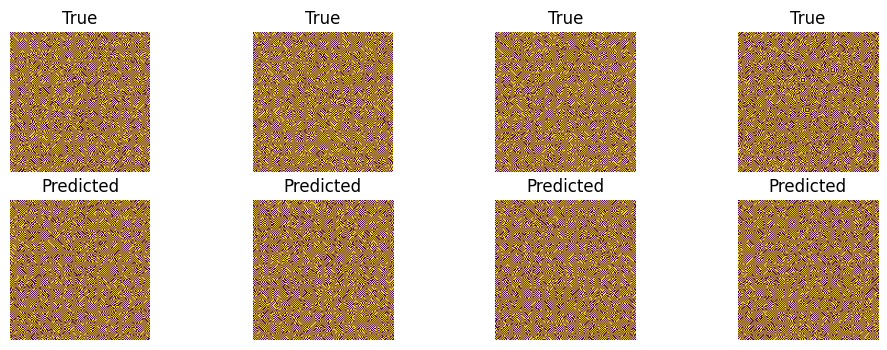

Sample 1:
True   : [0.07656642 0.06002422 0.24782199 0.0681463  0.75066674 0.18426594]
Predicted: [0.12668954 0.04167091 0.10205907 0.06179717 0.66097784 0.11089231]
-----
Sample 2:
True   : [0.07746221 0.05085039 0.2695006  0.07487277 0.52932334 0.09237086]
Predicted: [0.12735403 0.04680501 0.10445641 0.0618559  0.6399552  0.09842737]
-----
Sample 3:
True   : [0.03664317 0.0421335  0.05969982 0.06517115 0.2222868  0.24313682]
Predicted: [0.12792028 0.04680854 0.10487841 0.06235059 0.64372844 0.0996539 ]
-----
Sample 4:
True   : [0.04142625 0.04481354 0.5087547  0.07672466 0.5324006  0.16435382]
Predicted: [0.1111795  0.04481646 0.09170236 0.04791723 0.54154176 0.06850883]
-----


In [14]:
# -----------------------------
# Part 3: Training & Evaluation
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# Training function
# -----------------------------
def train(model, simulator, dataset, device='cuda', epochs=20, batch_size=16, lr=3e-4):
    model.to(device)
    model.train()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(1, epochs+1):
        running_loss = 0.0
        for imgs, params in loader:
            imgs = imgs.to(device)
            params = params.to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, params)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)

        epoch_loss = running_loss / len(dataset)
        print(f"Epoch {epoch}/{epochs} - Loss: {epoch_loss:.6f}")

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate(model, simulator, dataset, device='cuda', n_samples=4):
    model.to(device)
    model.eval()

    loader = DataLoader(dataset, batch_size=n_samples, shuffle=True)
    imgs, true_params = next(iter(loader))
    imgs = imgs.to(device)
    true_params = true_params.to(device)

    with torch.no_grad():
        preds = model(imgs)
        # generate patterns from predicted params
        pred_patterns = simulator(preds)
        true_patterns = simulator(true_params)

    # visualize
    imgs_to_show = n_samples
    plt.figure(figsize=(12,4))
    for i in range(imgs_to_show):
        plt.subplot(2, n_samples, i+1)
        plt.imshow(true_patterns[i,0].cpu(), cmap='viridis')
        plt.title("True")
        plt.axis('off')

        plt.subplot(2, n_samples, i+1+n_samples)
        plt.imshow(pred_patterns[i,0].cpu(), cmap='viridis')
        plt.title("Predicted")
        plt.axis('off')
    plt.show()

    # print predicted vs true params
    for i in range(n_samples):
        print(f"Sample {i+1}:")
        print("True   :", true_params[i].cpu().numpy())
        print("Predicted:", preds[i].cpu().numpy())
        print("-----")

# -----------------------------
# Example usage in Colab
# -----------------------------
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Assumes Part1 + Part2 are already executed in previous cells
    sim = GrayScottSimulator(img_size=128, steps=50, device=device)
    dataset = GrayScottDataset(n_samples=200, simulator=sim, precompute=False, device=device)
    model = GrayScottEncoder(img_channels=1, param_dim=6, img_size=128).to(device)

    print("Starting training...")
    train(model, sim, dataset, device=device, epochs=5, batch_size=8, lr=3e-4)

    print("Evaluating...")
    evaluate(model, sim, dataset, device=device, n_samples=4)